In [1]:
import sys
import subprocess

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--force-reinstall",
        "nltk"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

Defaulting to user installation because normal site-packages is not writeable
  Using cached nltk-3.10.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached regex-2026.7.19-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)
Using cached regex-2026.7.19-cp314-cp314-win_amd64.whl (280 kB)
Using cached click-8.4.2-py3-none-any.whl (119 kB)
Using cached colorama-0.4.6-py2.py3-none-any.whl (25 kB)
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)

  Attempting uninstall: regex

    Found existing installation: regex 2026.7.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
import nltk
nltk.download("stopwords")

print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
twitter_data = pd.read_csv(
    "sentiment.csv",
    encoding="latin-1",
    header=None,
    names=["target", "id", "date", "flag", "user", "text"]
)

In [5]:
twitter_data.head(10)

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


In [6]:

twitter_data.shape

(1600000, 6)

In [7]:
twitter_data.isnull().sum()

target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

In [8]:
twitter_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   target  1600000 non-null  int64
 1   id      1600000 non-null  int64
 2   date    1600000 non-null  str  
 3   flag    1600000 non-null  str  
 4   user    1600000 non-null  str  
 5   text    1600000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 256.9 MB


In [9]:
twitter_data["target"].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

In [10]:
twitter_data["text"].duplicated().sum()

np.int64(18534)

In [11]:
twitter_data["text"].sample(10, random_state=42).tolist()

['@chrishasboobs AHHH I HOPE YOUR OK!!! ',
 '@misstoriblack cool , i have no tweet apps  for my razr 2',
 '@TiannaChaos i know  just family drama. its lame.hey next time u hang out with kim n u guys like have a sleepover or whatever, ill call u',
 "School email won't open  and I have geography stuff on there to revise! *Stupid School* :'(",
 'upper airways problem ',
 "Going to miss Pastor's sermon on Faith... ",
 'on lunch....dj should come eat with me ',
 '@piginthepoke oh why are you feeling like that? ',
 'gahh noo!peyton needs to live!this is horrible ',
 '@mrstessyman thank you glad you like it! There is a product review bit on the site  Enjoy knitting it!']

Convert the target from 4 to 1

In [12]:
twitter_data["target"].unique()

array([0, 4])

In [13]:
twitter_data["sentiment"]=twitter_data["target"].map({
    0:'negative',
    4:'positive'
})

In [14]:
twitter_data["target"] = twitter_data["target"].replace({4: 1})

In [15]:
twitter_data[["target", "sentiment"]].head()

,target,sentiment
0,0,negative
1,0,negative
2,0,negative
3,0,negative
4,0,negative


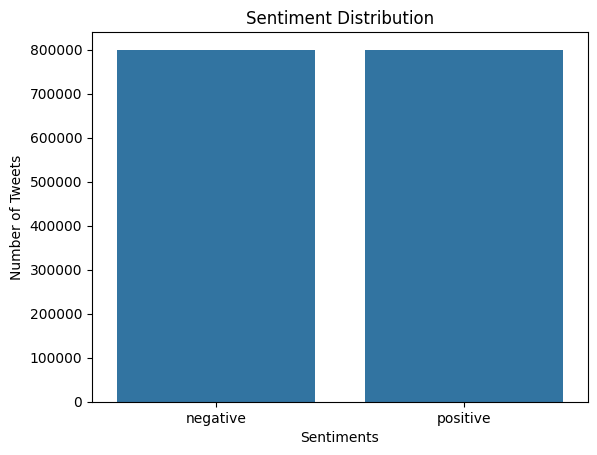

In [16]:
#visualize the sentiment distribution.

sns.countplot(data=twitter_data,x="sentiment")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiments")
plt.ylabel("Number of Tweets")
plt.show()

 0----> means negative
 
 1----> means positive

Stemming : process of reducing a word to its root word

ex: actor ,actress, acting, =act

In [17]:
# port_stem=PorterStemmer()

# def stemming(content):
#     stemmed_content=re.sub('[^a-zA-Z]',' ',content)
#     stemmed_content=stemmed_content.lower()
#     stemmed_content=stemmed_content.split()
#     stemmed_content=[port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
#     stemmed_content=' '.join(stemmed_content)
    
#     return stemmed_content

In [18]:
import re

def clean_text(text):
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove @mentions
    text = re.sub(r"@\w+", "", text)
    
    # Remove non-alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [19]:
twitter_data["clean_text"] = twitter_data["text"].apply(clean_text)

In [20]:
twitter_data[["text", "clean_text"]].sample(10, random_state=42)

,text,clean_text
541200,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh i hope your ok
750,"@misstoriblack cool , i have no tweet apps fo...",cool i have no tweet apps for my razr
766711,@TiannaChaos i know just family drama. its la...,i know just family drama its lamehey next time...
285055,School email won't open and I have geography ...,school email wont open and i have geography st...
705995,upper airways problem,upper airways problem
379611,Going to miss Pastor's sermon on Faith...,going to miss pastors sermon on faith
1189018,on lunch....dj should come eat with me,on lunchdj should come eat with me
667030,@piginthepoke oh why are you feeling like that?,oh why are you feeling like that
93541,gahh noo!peyton needs to live!this is horrible,gahh noopeyton needs to livethis is horrible
1097326,@mrstessyman thank you glad you like it! There...,thank you glad you like it there is a product ...


In [21]:
twitter_data["clean_text"].isna().sum()

np.int64(0)

In [22]:
twitter_data.shape

(1600000, 8)

In [23]:
X = twitter_data["clean_text"].to_numpy(dtype=object)

y = twitter_data["target"].to_numpy()

In [24]:
print(type(X))
print(type(y))

print(X.shape)
print(y.shape)

print(np.unique(y, return_counts=True))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(1600000,)
(1600000,)
(array([0, 1]), array([800000, 800000]))


In [25]:
print(y)

[0 0 0 ... 1 1 1]


TRAIN TEST SPLIT DATA 


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2,
    stratify=y
)


In [27]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1280000,)
X_test: (320000,)
y_train: (1280000,)
y_test: (320000,)


In [28]:
print(X_train)

['about to watch saw iv and drink a lil wine' 'im in'
 'even though its my favourite drink i think its the vodka and coke that wipes my mind all the time think im gonna have to find a new drink'
 ... 'is eager for monday afternoon'
 'hope everyone and their mother had a great day cant wait to hear what the guys have in store tomorrow'
 'i love waking up to folgers too bad my voice was deeper than his']


In [29]:
print(X_test)

['m doing fine i havent had much time to chat on twitter hubby is back for the summer amp tends to dominate my free time'
 'at ahs may show w ruth kim amp geoffrey sanhueza'
 'maybe it was only a bay area thang dammit' ...
 'nevertheless hooray for members and have a wonderful and safe trip'
 'not feeling too well' 'thank you']


Text data to Numerical Data

In [30]:
Vectorizer=TfidfVectorizer()

X_train_vec=Vectorizer.fit_transform(X_train)
X_test_vec=Vectorizer.transform(X_test)

In [33]:
print(X_train_vec)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14153711 stored elements and shape (1280000, 358135)>
  Coords	Values
  (0, 1219)	0.24101412907843156
  (0, 312227)	0.12097726504196407
  (0, 337178)	0.30396816525851983
  (0, 267195)	0.3280875562041462
  (0, 149302)	0.4871490544746487
  (0, 11519)	0.1497290708549516
  (0, 82618)	0.38382773270605225
  (0, 169537)	0.38588624315372205
  (0, 344243)	0.4138522488965091
  (1, 142622)	0.7268247371813856
  (1, 143476)	0.6868229767714601
  (2, 312227)	0.07009666159294779
  (2, 11519)	0.08675603640655462
  (2, 82618)	0.4447950229351252
  (2, 142622)	0.1017704007510978
  (2, 92750)	0.1697146531379323
  (2, 308581)	0.16257639009362665
  (2, 148918)	0.23303747516626394
  (2, 198867)	0.17057110152364502
  (2, 98610)	0.2546030086992159
  (2, 307717)	0.2912702941921344
  (2, 305961)	0.14475202787666552
  (2, 334079)	0.28759693209856396
  (2, 57634)	0.2737428512276642
  (2, 305579)	0.10859974250236062
  :	:
  (1279998, 123890)	0.20949700808

In [34]:
print(X_test_vec)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3478435 stored elements and shape (320000, 358135)>
  Coords	Values
  (0, 10550)	0.16663905568672607
  (0, 21941)	0.15329640609279038
  (0, 50738)	0.2641102685545074
  (0, 79689)	0.19664323792517982
  (0, 79985)	0.4065852153140684
  (0, 101360)	0.241452672266188
  (0, 105285)	0.10748559185875503
  (0, 106947)	0.22439912612734406
  (0, 123890)	0.1588302570809101
  (0, 127693)	0.2107452054975787
  (0, 138239)	0.268300498906766
  (0, 147627)	0.10451712218063673
  (0, 196918)	0.16772250759279464
  (0, 198867)	0.09583032020748852
  (0, 214651)	0.11610326726067643
  (0, 295979)	0.20849825923658294
  (0, 303935)	0.39057712996486277
  (0, 305961)	0.0813246385712133
  (0, 310434)	0.30640612664511097
  (0, 312227)	0.1575269307854465
  (0, 322621)	0.17352460487617732
  (1, 6005)	0.5256496872543461
  (1, 10550)	0.1862190047357682
  (1, 17844)	0.1453050968204272
  (1, 113331)	0.5026829583643335
  :	:
  (319995, 167946)	0.2715163569787597

Lets Train ML model

In [35]:
lr_model=LogisticRegression(max_iter=1000)



In [37]:
lr_model.fit(X_train_vec,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Model Evaluation


In [41]:
#accuracy score training data

X_train_pred=lr_model.predict(X_train_vec)
training_data_acc=accuracy_score(y_train,X_train_pred)

In [42]:
print("Accuracy Score :",training_data_acc)

Accuracy Score : 0.81274453125


In [43]:
#accuracy score test data

X_test_pred=lr_model.predict(X_test_vec)
test_data_acc=accuracy_score(y_test,X_test_pred)

In [44]:
print("Accuracy Score :",test_data_acc)

Accuracy Score : 0.798978125


Model Accuracy 79%

Saving Trained model

In [45]:
import pickle

In [48]:
filename="Trained_model.pkl"
pickle.dump(lr_model,open(filename,"wb"))

loading saved model

In [52]:
loaded_model=pickle.load(open(r"C:\allcoding\ML-Projects\Setntiment-Analysis\Trained_model.pkl","rb"))

In [59]:
# X_new=X_test[200]
# print(y_test[200])
# X_new_tfidf = tfidf.transform([X_new])

# prediction=lr_model.predict(X_new)
# print(prediction)

# if (prediction[0]==0):
#     print("negative tweet")
# else:
#     print("Positive Tweet")



X_new = X_test[200]

print("Tweet:", X_new)

X_new_vec = Vectorizer.transform([X_new])

prediction = lr_model.predict(X_new_vec)

print("Prediction:", prediction)

if prediction[0] == 0:
    print("Negative Tweet")
else:
    print("Positive Tweet")

Tweet: loves when she is having a sucky day and she gets an unexpected text that puts a smile on her face
Prediction: [1]
Positive Tweet
